In [5]:
import pandas as pd
import numpy as np
from datasets import load_dataset

In [6]:

seed = 42
data = load_dataset("Tobi-Bueck/customer-support-tickets")["train"]
df = data.to_pandas().reset_index(drop=True)

train_idx = np.loadtxt(
    "https://raw.githubusercontent.com/ikanam-ai/NLP-2026/main/homework/data/train_idx.txt",
    dtype=int
)

val_idx = np.loadtxt(
    "https://raw.githubusercontent.com/ikanam-ai/NLP-2026/main/homework/data/val_idx.txt",
    dtype=int
)

test_idx = np.loadtxt(
    "https://raw.githubusercontent.com/ikanam-ai/NLP-2026/main/homework/data/test_idx.txt",
    dtype=int
)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

49412 6176 6177


In [7]:
import matplotlib.pyplot as plt


def run_ticket_eda(train_df, val_df, test_df):
    """
    EDA for customer support tickets dataset on train/val/test splits.

    Expected columns:
    - subject
    - body
    - queue
    - priority
    - type
    """

    def _prepare_split(df, split_name):
        df = df.copy()

        # Fill missing text fields safely
        if "subject" in df.columns:
            df["subject"] = df["subject"].fillna("").astype(str)
        else:
            df["subject"] = ""

        if "body" in df.columns:
            df["body"] = df["body"].fillna("").astype(str)
        else:
            df["body"] = ""

        if "type" in df.columns:
            df["type"] = df["type"].fillna("Unknown").astype(str)
        else:
            df["type"] = "Unknown"

        if "queue" in df.columns:
            df["queue"] = df["queue"].fillna("Unknown").astype(str)
        else:
            df["queue"] = "Unknown"

        if "priority" in df.columns:
            df["priority"] = df["priority"].fillna("Unknown").astype(str)
        else:
            df["priority"] = "Unknown"

        # Text features
        df["full_text"] = (df["subject"].str.strip() + " " + df["body"].str.strip()).str.strip()

        df["subject_len_chars"] = df["subject"].apply(len)
        df["body_len_chars"] = df["body"].apply(len)
        df["text_len_chars"] = df["full_text"].apply(len)

        df["subject_len_words"] = df["subject"].apply(lambda x: len(x.split()))
        df["body_len_words"] = df["body"].apply(lambda x: len(x.split()))
        df["text_len_words"] = df["full_text"].apply(lambda x: len(x.split()))

        df["split"] = split_name
        return df

    # Prepare splits
    train_p = _prepare_split(train_df, "train")
    val_p = _prepare_split(val_df, "val")
    test_p = _prepare_split(test_df, "test")

    splits = {
        "train": train_p,
        "val": val_p,
        "test": test_p
    }

    print("=" * 90)
    print("DATASET OVERVIEW")
    print("=" * 90)

    for name, df in splits.items():
        print(f"\n[{name.upper()}]")
        print(f"Shape: {df.shape}")
        print("\nMissing values:")
        print(df[["subject", "body", "queue", "priority", "type"]].isna().sum())

    # Combine for shared plotting
    full_df = pd.concat([train_p, val_p, test_p], axis=0, ignore_index=True)

    print("\n" + "=" * 90)
    print("TEXT LENGTH SUMMARY")
    print("=" * 90)

    numeric_cols = [
        "subject_len_chars", "body_len_chars", "text_len_chars",
        "subject_len_words", "body_len_words", "text_len_words"
    ]

    summary_tables = []
    for name, df in splits.items():
        desc = df[numeric_cols].describe().T
        desc["split"] = name
        summary_tables.append(desc.reset_index().rename(columns={"index": "feature"}))

    summary_df = pd.concat(summary_tables, ignore_index=True)
    display(summary_df)

    print("\n" + "=" * 90)
    print("CATEGORY CARDINALITY")
    print("=" * 90)

    for target in ["queue", "priority", "type"]:
        print(f"\nTarget: {target}")
        for name, df in splits.items():
            print(f"  {name}: {df[target].nunique()} unique values")

    print("\n" + "=" * 90)
    print("TOP LABEL COUNTS")
    print("=" * 90)

    for target in ["queue", "priority", "type"]:
        print(f"\n[{target.upper()}]")
        for name, df in splits.items():
            print(f"\n{name}:")
            print(df[target].value_counts().head(10))

    # ---------------------------
    # Plot 1: split sizes
    # ---------------------------
    plt.figure(figsize=(8, 4))
    split_sizes = [len(train_p), len(val_p), len(test_p)]
    split_names = ["train", "val", "test"]
    plt.bar(split_names, split_sizes)
    plt.title("Split Sizes")
    plt.xlabel("Split")
    plt.ylabel("Number of samples")
    plt.show()

    # ---------------------------
    # Plot 2: missing values
    # ---------------------------
    missing_df = pd.DataFrame({
        split_name: df[["subject", "body", "queue", "priority", "type"]].isna().sum()
        for split_name, df in {
            "train": train_df,
            "val": val_df,
            "test": test_df
        }.items()
    })

    missing_df.plot(kind="bar", figsize=(10, 5))
    plt.title("Missing Values by Split")
    plt.xlabel("Column")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

    # ---------------------------
    # Plot 3: numeric distributions by split
    # ---------------------------
    for col in numeric_cols:
        plt.figure(figsize=(10, 4))
        for split_name, df in splits.items():
            plt.hist(df[col], bins=50, alpha=0.5, label=split_name)
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.legend()
        plt.show()

    # ---------------------------
    # Plot 4: boxplots for numeric features by split
    # ---------------------------
    for col in numeric_cols:
        data_to_plot = [
            train_p[col].dropna(),
            val_p[col].dropna(),
            test_p[col].dropna()
        ]
        plt.figure(figsize=(8, 4))
        plt.boxplot(data_to_plot, tick_labels=["train", "val", "test"], vert=False)
        plt.title(f"Boxplot of {col} by Split")
        plt.xlabel(col)
        plt.show()

    # ---------------------------
    # Plot 5: categorical distributions
    # ---------------------------
    for target in ["priority", "type"]:
        categories = sorted(full_df[target].dropna().unique().tolist())

        x = np.arange(len(categories))
        width = 0.25

        train_counts = train_p[target].value_counts().reindex(categories, fill_value=0)
        val_counts = val_p[target].value_counts().reindex(categories, fill_value=0)
        test_counts = test_p[target].value_counts().reindex(categories, fill_value=0)

        plt.figure(figsize=(12, 5))
        plt.bar(x - width, train_counts.values, width=width, label="train")
        plt.bar(x, val_counts.values, width=width, label="val")
        plt.bar(x + width, test_counts.values, width=width, label="test")
        plt.xticks(x, categories, rotation=45)
        plt.title(f"Distribution of {target} by Split")
        plt.xlabel(target)
        plt.ylabel("Count")
        plt.legend()
        plt.show()

    # ---------------------------
    # Plot 6: queue top-20 per split
    # ---------------------------
    for split_name, df in splits.items():
        counts = df["queue"].value_counts().head(20)
        plt.figure(figsize=(12, 5))
        plt.bar(counts.index.astype(str), counts.values)
        plt.title(f"Top-20 Queue Classes ({split_name})")
        plt.xlabel("Queue")
        plt.ylabel("Count")
        plt.xticks(rotation=90)
        plt.show()

    # ---------------------------
    # Plot 7: percent of top-20 queue classes
    # ---------------------------
    for split_name, df in splits.items():
        counts = df["queue"].value_counts(normalize=True).head(20) * 100
        plt.figure(figsize=(12, 5))
        plt.bar(counts.index.astype(str), counts.values)
        plt.title(f"Top-20 Queue Class Share (%) ({split_name})")
        plt.xlabel("Queue")
        plt.ylabel("Percent")
        plt.xticks(rotation=90)
        plt.show()

    # ---------------------------
    # Final comparison table
    # ---------------------------
    comparison_rows = []
    for split_name, df in splits.items():
        comparison_rows.append({
            "split": split_name,
            "n_rows": len(df),
            "n_queue_classes": df["queue"].nunique(),
            "n_priority_classes": df["priority"].nunique(),
            "n_type_classes": df["type"].nunique(),
            "mean_text_len_words": df["text_len_words"].mean(),
            "median_text_len_words": df["text_len_words"].median(),
            "mean_text_len_chars": df["text_len_chars"].mean(),
            "median_text_len_chars": df["text_len_chars"].median(),
        })

    comparison_df = pd.DataFrame(comparison_rows)
    print("\n" + "=" * 90)
    print("SPLIT COMPARISON TABLE")
    print("=" * 90)
    display(comparison_df)

    print("\nEDA finished successfully.")

DATASET OVERVIEW

[TRAIN]
Shape: (49412, 24)

Missing values:
subject     0
body        0
queue       0
priority    0
type        0
dtype: int64

[VAL]
Shape: (6176, 24)

Missing values:
subject     0
body        0
queue       0
priority    0
type        0
dtype: int64

[TEST]
Shape: (6177, 24)

Missing values:
subject     0
body        0
queue       0
priority    0
type        0
dtype: int64

TEXT LENGTH SUMMARY


,feature,count,mean,std,min,25%,50%,75%,max,split
0,subject_len_chars,49412.0,43.347648,23.211045,0.0,31.0,43.0,56.0,675.0,train
1,body_len_chars,49412.0,419.406986,223.607335,0.0,233.0,415.0,587.0,2259.0,train
2,text_len_chars,49412.0,463.666397,226.852166,4.0,278.0,459.0,633.0,2284.0,train
3,subject_len_words,49412.0,5.067696,2.765279,0.0,4.0,5.0,7.0,77.0,train
4,body_len_words,49412.0,57.377742,30.999331,0.0,31.0,57.0,82.0,281.0,train
5,text_len_words,49412.0,62.445438,31.205693,1.0,37.0,62.0,87.0,283.0,train
6,subject_len_chars,6176.0,43.565900,21.658682,0.0,32.0,43.0,56.0,209.0,val
7,body_len_chars,6176.0,421.162889,224.215954,13.0,238.0,421.0,591.0,1632.0,val
8,text_len_chars,6176.0,465.645725,227.123185,18.0,282.0,462.0,637.0,1677.0,val
9,subject_len_words,6176.0,5.087111,2.605169,0.0,4.0,5.0,7.0,26.0,val



CATEGORY CARDINALITY

Target: queue
  train: 52 unique values
  val: 52 unique values
  test: 52 unique values

Target: priority
  train: 5 unique values
  val: 5 unique values
  test: 5 unique values

Target: type
  train: 5 unique values
  val: 5 unique values
  test: 5 unique values

TOP LABEL COUNTS

[QUEUE]

train:
queue
Technical Support                  11354
Product Support                     7139
Customer Service                    5905
IT Support                          4673
Billing and Payments                3853
Returns and Exchanges               1956
Service Outages and Maintenance     1534
Sales and Pre-Sales                 1228
Human Resources                      730
General Inquiry                      532
Name: count, dtype: int64

val:
queue
Technical Support                  1414
Product Support                     884
Customer Service                    749
IT Support                          537
Billing and Payments                489
Returns and Exchanges  

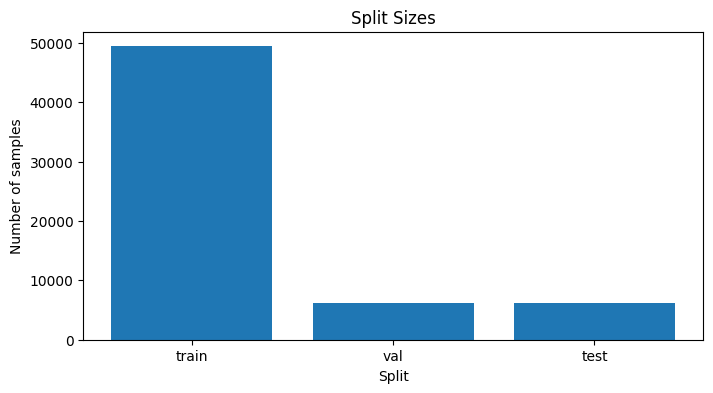

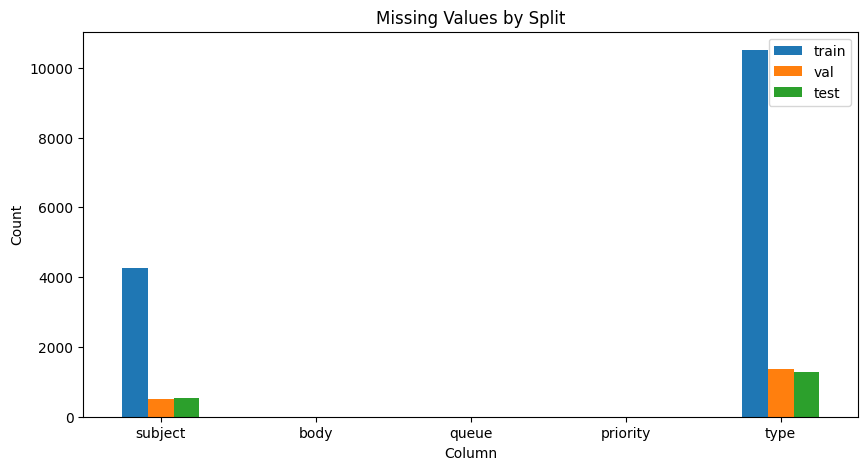

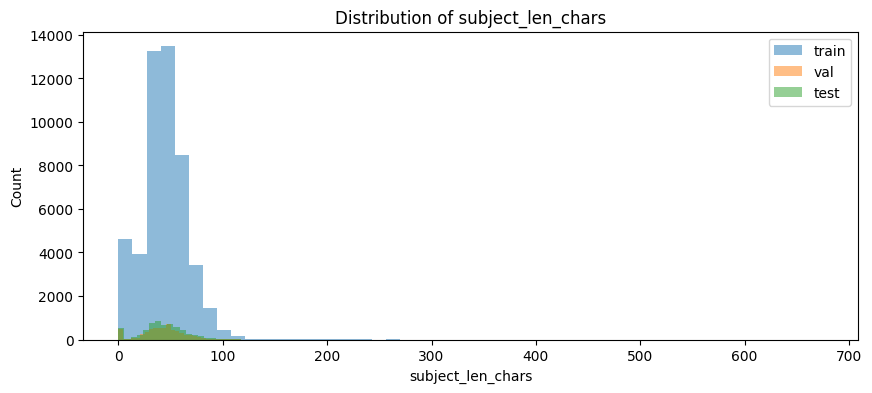

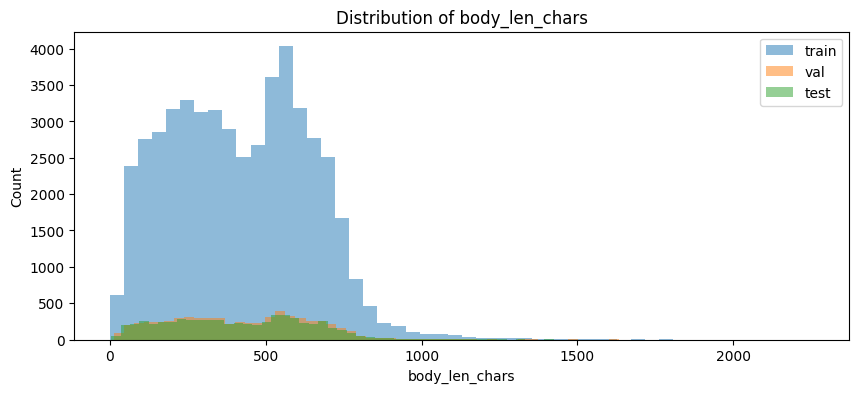

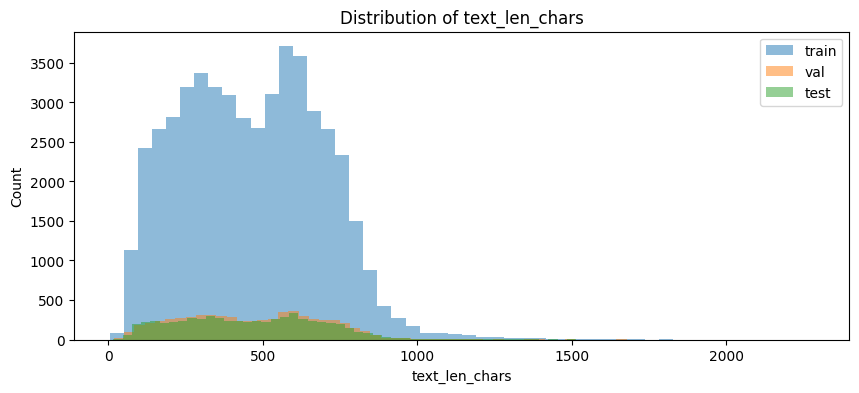

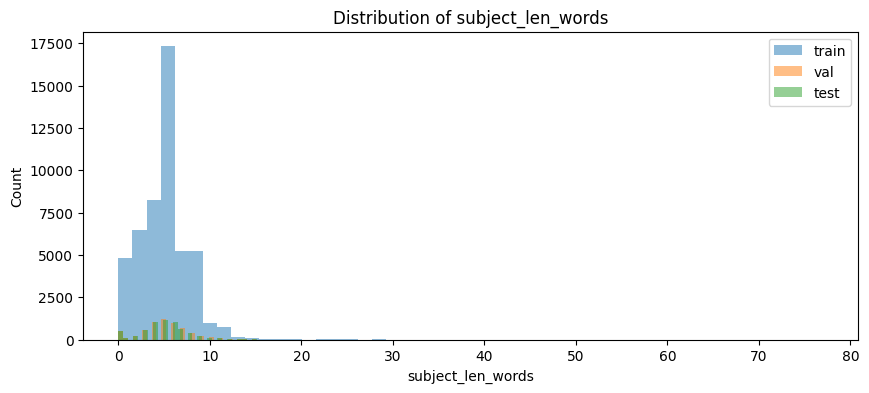

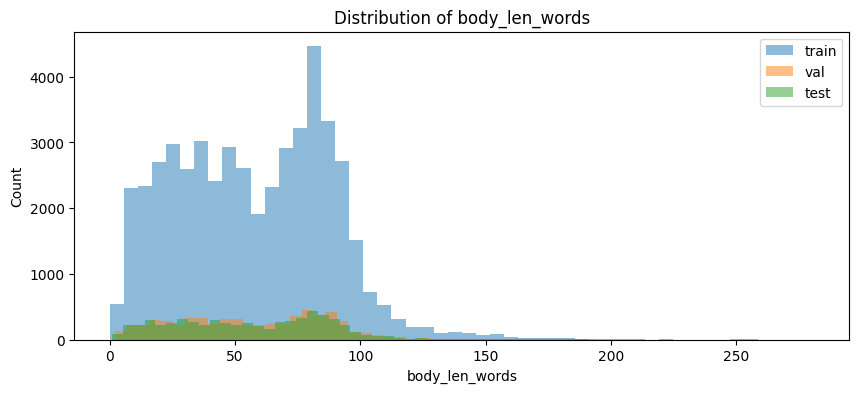

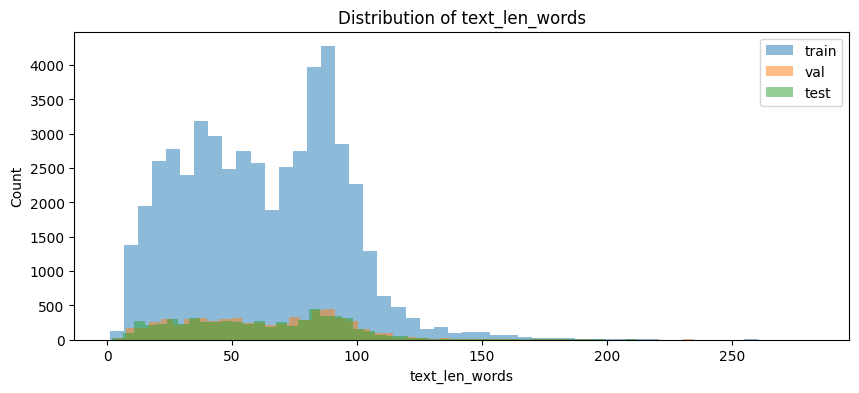

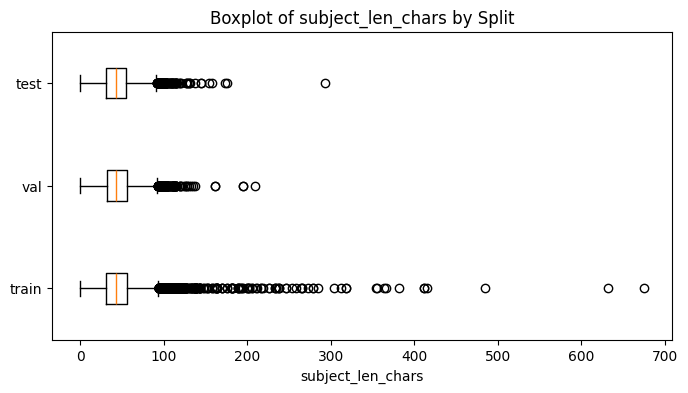

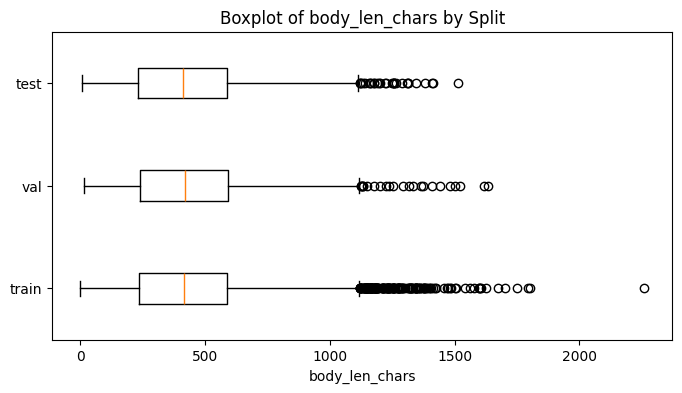

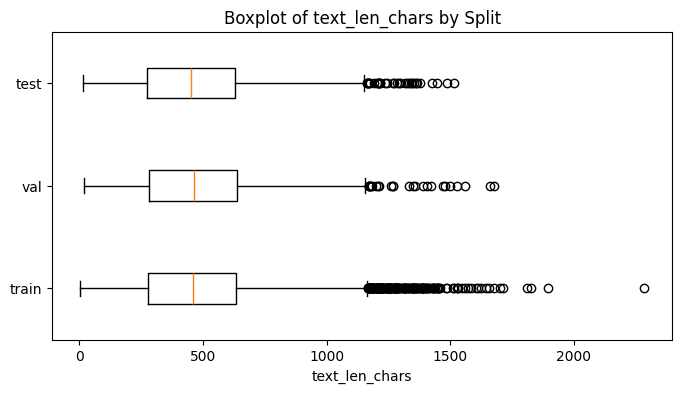

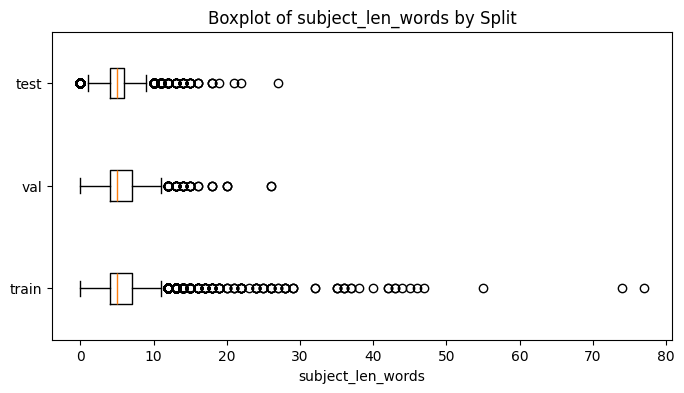

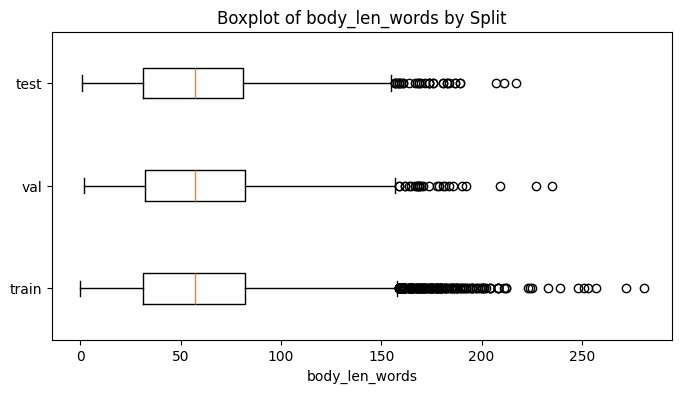

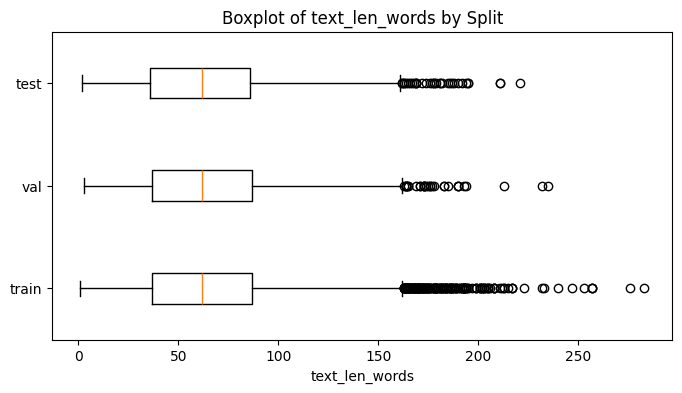

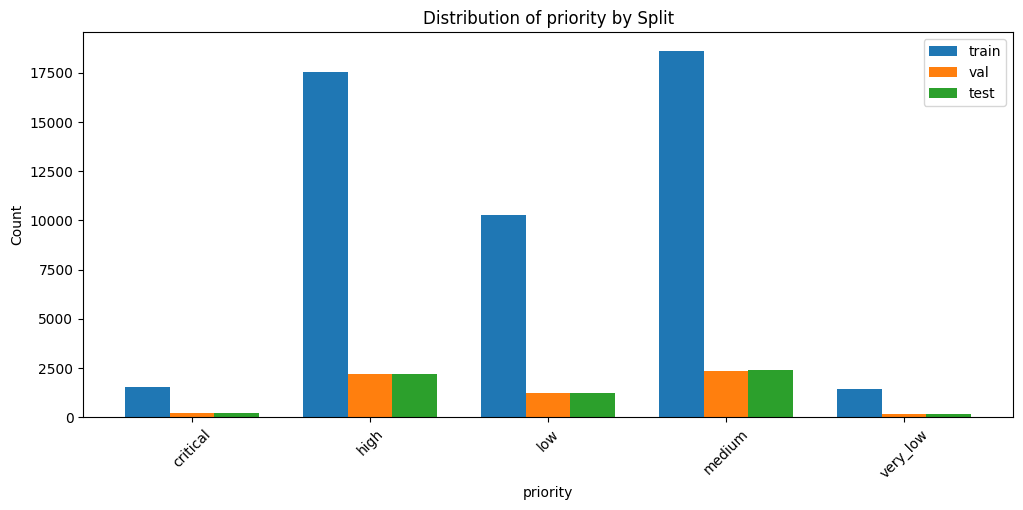

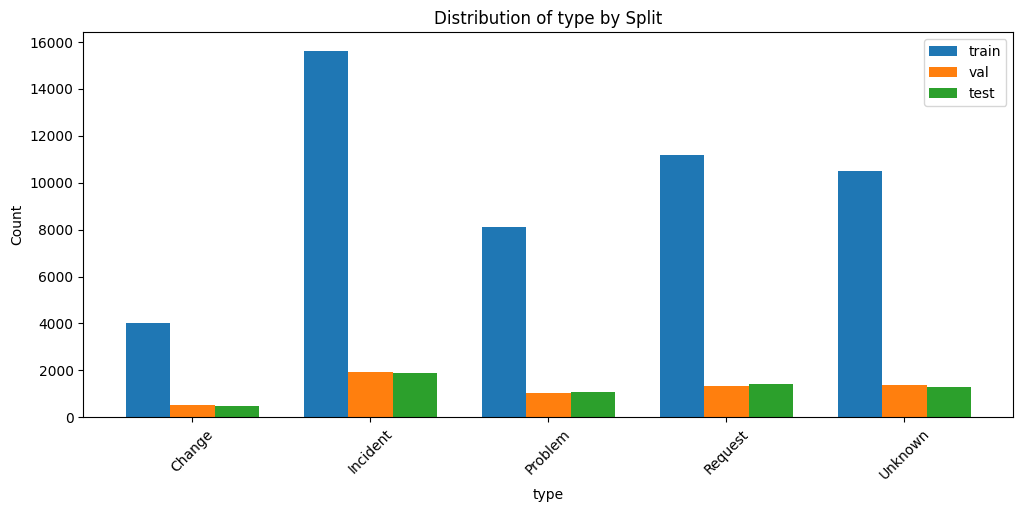

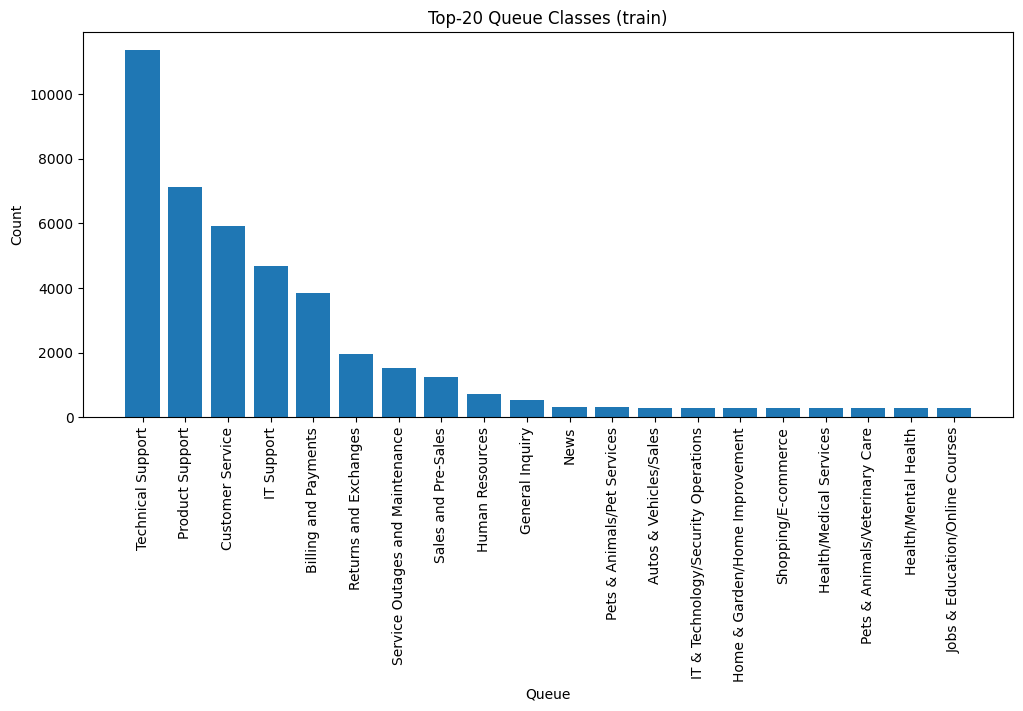

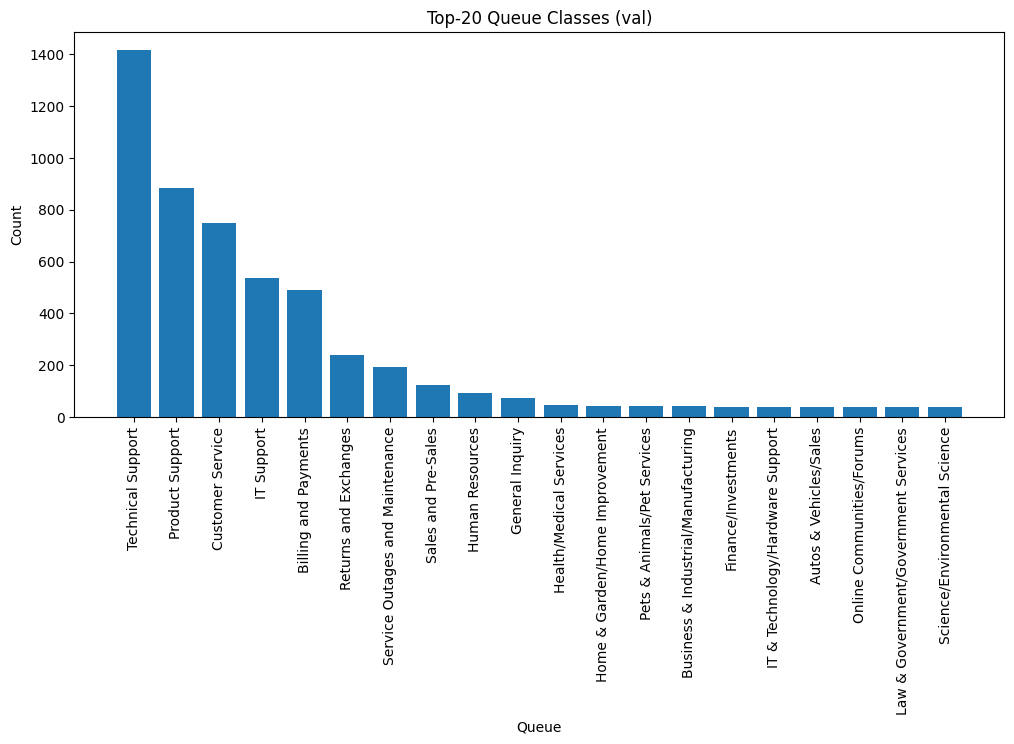

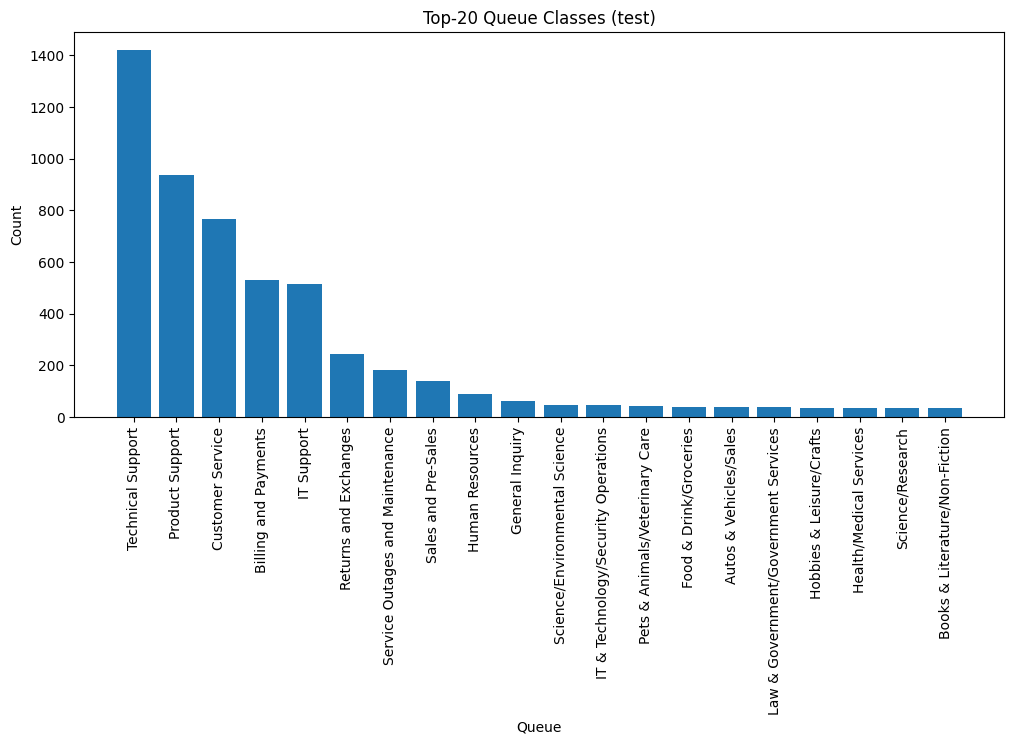

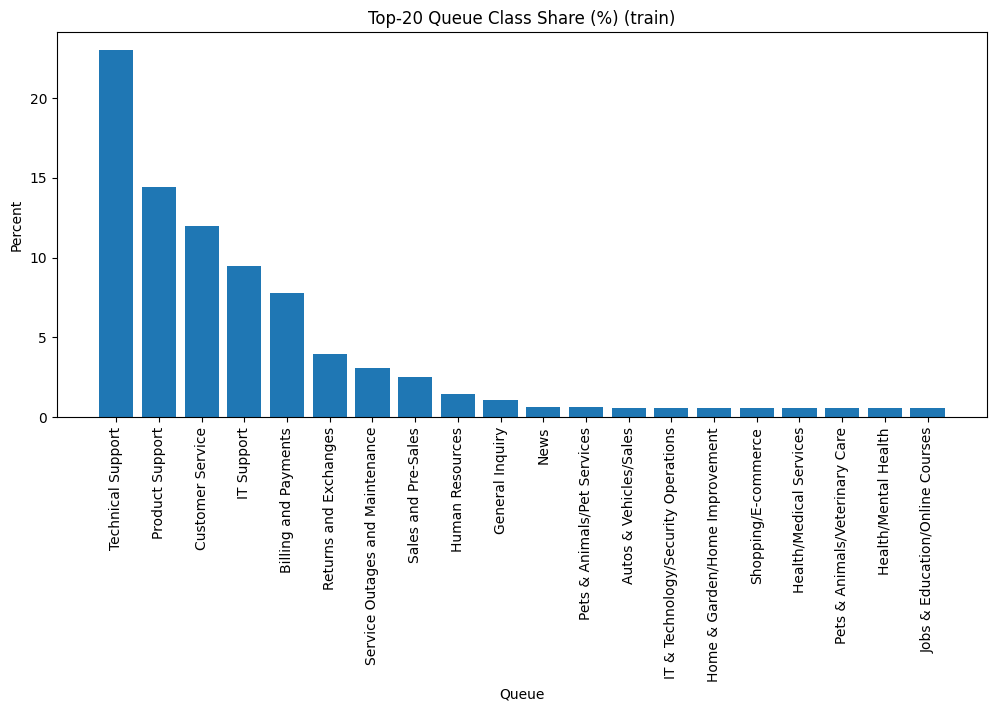

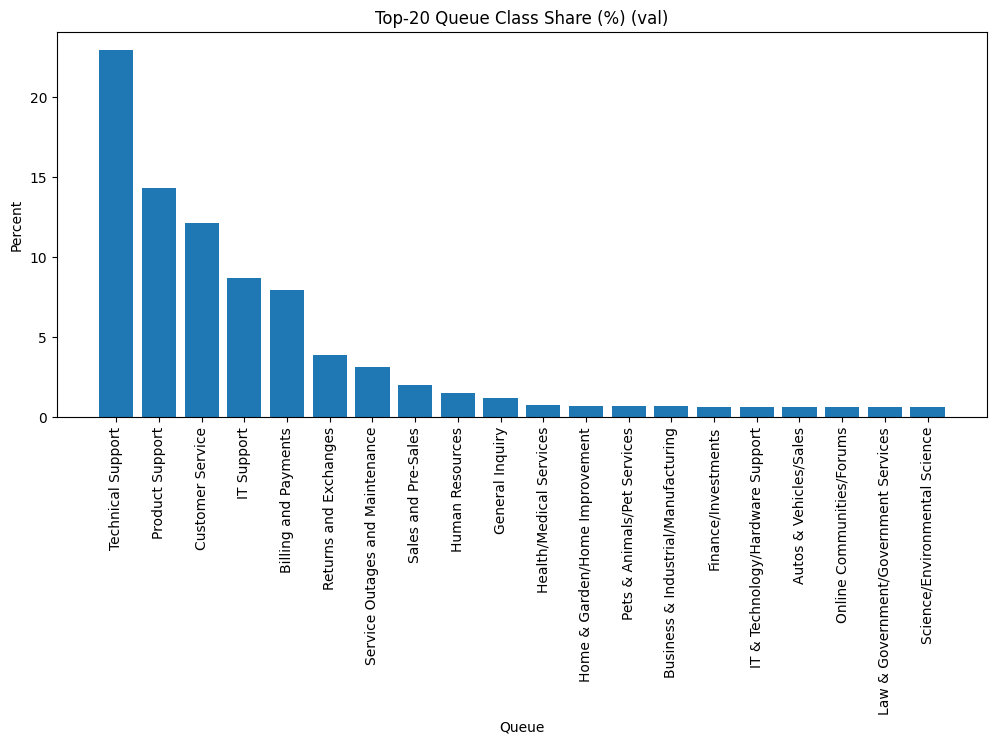

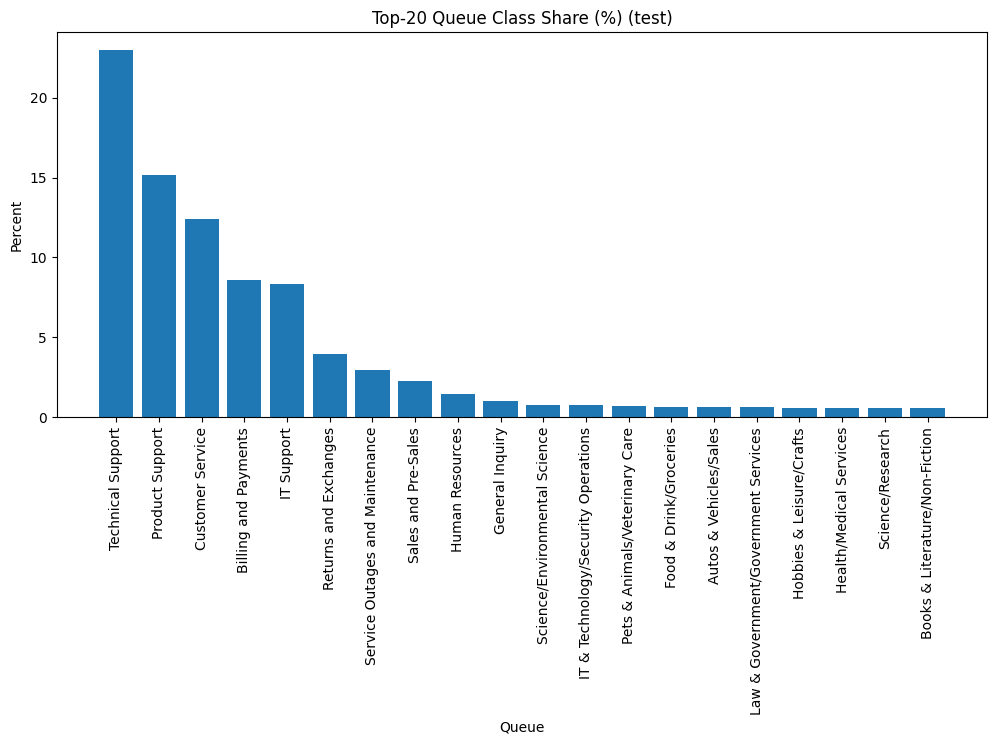


SPLIT COMPARISON TABLE


,split,n_rows,n_queue_classes,n_priority_classes,n_type_classes,mean_text_len_words,median_text_len_words,mean_text_len_chars,median_text_len_chars
0,train,49412,52,5,5,62.445438,62.0,463.666397,459.0
1,val,6176,52,5,5,62.664670,62.0,465.645725,462.0
2,test,6177,52,5,5,62.062490,62.0,459.242836,453.0



EDA finished successfully.


In [8]:
run_ticket_eda(train_df, val_df, test_df)

In [9]:
import pandas as pd

def base_model(train_df, val_df, test_df):
    from sklearn.preprocessing import LabelEncoder
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import f1_score, accuracy_score
    from sklearn.svm import LinearSVC

    # preproc
    def preproc(df):
        df = df.copy()
        df["subject"] = df["subject"].fillna("").astype(str)
        df["body"] = df["body"].fillna("").astype(str)
        df["text"] = (
            df["subject"].str.strip() + " " + df["body"].str.strip()
        ).str.replace(r"\s+", " ", regex=True).str.strip()
        return df

    train_df = preproc(train_df)
    val_df = preproc(val_df)
    test_df = preproc(test_df)

    # encoder
    label = LabelEncoder()
    y_train = label.fit_transform(train_df["queue"])
    y_val = label.transform(val_df["queue"])
    y_test = label.transform(test_df["queue"])

    # tf-idf
    tfidf = TfidfVectorizer(
        ngram_range=(1, 1),
        min_df=5,
        max_features=5000,
        sublinear_tf=True,
    )

    X_train = tfidf.fit_transform(train_df["text"])
    X_val = tfidf.transform(val_df["text"])
    X_test = tfidf.transform(test_df["text"])

    print("Shapes:")
    print("X_train:", X_train.shape)
    print("X_val:", X_val.shape)
    print("X_test:", X_test.shape)

    # base model
    # clf = LogisticRegression(
    #     max_iter=1000,
    #     class_weight="balanced",   #"balanced"
    #     solver="liblinear",
    #     n_jobs=-1
    # )

    clf = LinearSVC(class_weight="balanced")
    clf.fit(X_train, y_train)

    # pred
    val_pred = clf.predict(X_val)
    test_pred = clf.predict(X_test)

    # metrics
    def calculate_metrics(y_true, y_pred, split_name="split"):
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        acc = accuracy_score(y_true, y_pred)

        print(f"\n{split_name} results")
        print(f"Macro-F1(queue): {macro_f1:.4f}")
        print(f"Accuracy(queue): {acc:.4f}")

        return {
            "model": "TF-IDF + LogisticRegression",
            "split": split_name,
            "macro_f1_queue": macro_f1,
            "accuracy_queue": acc
        }

    val_metrics = calculate_metrics(y_val, val_pred, split_name="val")
    test_metrics = calculate_metrics(y_test, test_pred, split_name="test")

    results_baseline = pd.DataFrame([val_metrics, test_metrics])
    display(results_baseline)

    return clf, tfidf, label, results_baseline

clf, tfidf, label, results_baseline = base_model(train_df, val_df, test_df)

Shapes:
X_train: (49412, 5000)
X_val: (6176, 5000)
X_test: (6177, 5000)

val results
Macro-F1(queue): 0.7649
Accuracy(queue): 0.4895

test results
Macro-F1(queue): 0.7471
Accuracy(queue): 0.4740


,model,split,macro_f1_queue,accuracy_queue
0,TF-IDF + LogisticRegression,val,0.764913,0.489475
1,TF-IDF + LogisticRegression,test,0.747107,0.474017


### Transformer

In [10]:
def trf_mod_best_head(train_df, val_df, test_df,batch_size=64):
    import numpy as np
    import pandas as pd
    import torch

    from sklearn.preprocessing import LabelEncoder
    from sklearn.linear_model import LogisticRegression
    from sklearn.svm import LinearSVC
    from sklearn.metrics import f1_score, accuracy_score, classification_report

    from sentence_transformers import SentenceTransformer

  
    print("CUDA available:", torch.cuda.is_available())
    device = "cuda" if torch.cuda.is_available() else "cpu"

    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("GPU не найдена, всё будет работать на CPU")

   
    def preproc(df):
        df = df.copy()
        df["subject"] = df["subject"].fillna("").astype(str)
        df["body"] = df["body"].fillna("").astype(str)
        df["text"] = (
            df["subject"].str.strip() + " " + df["body"].str.strip()
        ).str.replace(r"\s+", " ", regex=True).str.strip()
        return df

    train_df = preproc(train_df)
    val_df = preproc(val_df)
    test_df = preproc(test_df)

    print("\nПример данных:")
    print(train_df[["text", "queue"]].head(3))


    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_df["queue"])
    y_val = label_encoder.transform(val_df["queue"])
    y_test = label_encoder.transform(test_df["queue"])

    print("\nЧисло классов:", len(label_encoder.classes_))
    print("Первые классы:", list(label_encoder.classes_)[:10])

    
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
    embedder = SentenceTransformer(model_name, device=device)

    print("\nLoaded model:", model_name)
    print("Using device:", device)

    
    X_train_emb = embedder.encode(
        train_df["text"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    X_val_emb = embedder.encode(
        val_df["text"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    X_test_emb = embedder.encode(
        test_df["text"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    print("\nEmbedding shapes:")
    print("X_train_emb:", X_train_emb.shape)
    print("X_val_emb:", X_val_emb.shape)
    print("X_test_emb:", X_test_emb.shape)

    
    clf_log = LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    )

    clf_svc = LinearSVC(
        class_weight="balanced"
    )

    print("\nTraining LogisticRegression...")
    clf_log.fit(X_train_emb, y_train)

    print("Training LinearSVC...")
    clf_svc.fit(X_train_emb, y_train)

   
    val_pred_log = clf_log.predict(X_val_emb)
    val_pred_svc = clf_svc.predict(X_val_emb)

    val_f1_log = f1_score(y_val, val_pred_log, average="macro")
    val_f1_svc = f1_score(y_val, val_pred_svc, average="macro")

    print("\nValidation comparison:")
    print(f"LogisticRegression Macro-F1: {val_f1_log:.4f}")
    print(f"LinearSVC          Macro-F1: {val_f1_svc:.4f}")

    if val_f1_log >= val_f1_svc:
        best_clf = clf_log
        best_model_name = "SentenceTransformer + LogisticRegression"
        print("\nBest head selected: LogisticRegression")
    else:
        best_clf = clf_svc
        best_model_name = "SentenceTransformer + LinearSVC"
        print("\nBest head selected: LinearSVC")

   
    val_pred = best_clf.predict(X_val_emb)
    test_pred = best_clf.predict(X_test_emb)

   
    def calculate_metrics(y_true, y_pred, split_name="split"):
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        acc = accuracy_score(y_true, y_pred)

        print(f"\n{split_name} results")
        print(f"Macro-F1(queue): {macro_f1:.4f}")
        print(f"Accuracy(queue): {acc:.4f}")

        return {
            "model": best_model_name,
            "split": split_name,
            "macro_f1_queue": macro_f1,
            "accuracy_queue": acc
        }

    val_metrics = calculate_metrics(y_val, val_pred, split_name="val")
    test_metrics = calculate_metrics(y_test, test_pred, split_name="test")

    results = pd.DataFrame([val_metrics, test_metrics])

    print("\nResults table:")
    display(results)


    print("\nVAL classification report:\n")
    print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

    print("\nTEST classification report:\n")
    print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

    return {
        "best_classifier": best_clf,
        "best_model_name": best_model_name,
        "embedder": embedder,
        "label_encoder": label_encoder,
        "X_train_emb": X_train_emb,
        "X_val_emb": X_val_emb,
        "X_test_emb": X_test_emb,
        "results": results,
        "val_f1_logreg": val_f1_log,
        "val_f1_linearsvc": val_f1_svc
    }

In [11]:
output_trf = trf_mod_best_head(train_df, val_df, test_df)
comparison = pd.concat(
    [results_baseline, output_trf["results"]],
    axis=0,
    ignore_index=True
)
display(comparison)

CUDA available: True
GPU: Tesla T4

Пример данных:
                                                text                  queue
0  Wesentlicher Sicherheitsvorfall Sehr geehrtes ...      Technical Support
1  Account Disruption Dear Customer Support Team,...      Technical Support
2  Query About Smart Home System Integration Feat...  Returns and Exchanges

Число классов: 52
Первые классы: ['Arts & Entertainment/Movies', 'Arts & Entertainment/Music', 'Autos & Vehicles/Maintenance', 'Autos & Vehicles/Sales', 'Beauty & Fitness/Cosmetics', 'Beauty & Fitness/Fitness Training', 'Billing and Payments', 'Books & Literature/Fiction', 'Books & Literature/Non-Fiction', 'Business & Industrial/Manufacturing']


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/97 [00:00<?, ?it/s]


Embedding shapes:
X_train_emb: (49412, 384)
X_val_emb: (6176, 384)
X_test_emb: (6177, 384)

Training LogisticRegression...
Training LinearSVC...

Validation comparison:
LogisticRegression Macro-F1: 0.6432
LinearSVC          Macro-F1: 0.6411

Best head selected: LogisticRegression

val results
Macro-F1(queue): 0.6432
Accuracy(queue): 0.3705

test results
Macro-F1(queue): 0.6322
Accuracy(queue): 0.3727

Results table:


,model,split,macro_f1_queue,accuracy_queue
0,SentenceTransformer + LogisticRegression,val,0.643211,0.370466
1,SentenceTransformer + LogisticRegression,test,0.632154,0.372673



VAL classification report:

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.85      0.97      0.90        29
            Arts & Entertainment/Music       0.80      0.90      0.85        31
          Autos & Vehicles/Maintenance       0.62      0.70      0.66        30
                Autos & Vehicles/Sales       0.66      0.69      0.68        39
            Beauty & Fitness/Cosmetics       0.88      0.81      0.84        26
     Beauty & Fitness/Fitness Training       0.92      0.96      0.94        23
                  Billing and Payments       0.65      0.59      0.62       489
            Books & Literature/Fiction       0.77      0.83      0.80        29
        Books & Literature/Non-Fiction       0.56      0.94      0.70        32
   Business & Industrial/Manufacturing       0.71      0.91      0.80        43
                      Customer Service       0.29      0.15      0.20       749
          

,model,split,macro_f1_queue,accuracy_queue
0,TF-IDF + LogisticRegression,val,0.764913,0.489475
1,TF-IDF + LogisticRegression,test,0.747107,0.474017
2,SentenceTransformer + LogisticRegression,val,0.643211,0.370466
3,SentenceTransformer + LogisticRegression,test,0.632154,0.372673


In [14]:
def distilbert_logreg_model(
    train_df,
    val_df,
    test_df,
    model_name="distilbert-base-uncased",
    max_length=128,
    batch_size=32,
    normalize_embeddings=True,
    logreg_max_iter=2000
):
    import numpy as np
    import pandas as pd
    import torch

    from tqdm.auto import tqdm
    from sklearn.preprocessing import LabelEncoder
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import f1_score, accuracy_score, classification_report
    from transformers import AutoTokenizer, AutoModel

    # =========================
    # 1. device
    # =========================
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("GPU не найдена, всё будет работать на CPU")

    # =========================
    # 2. preprocessing
    # =========================
    def preproc(df):
        df = df.copy()

        df["subject"] = df["subject"].fillna("").astype(str)
        df["body"] = df["body"].fillna("").astype(str)

        df["subject"] = df["subject"].str.replace(r"\s+", " ", regex=True).str.strip()
        df["body"] = df["body"].str.replace(r"\s+", " ", regex=True).str.strip()

        df["subject"] = df["subject"].str.replace(r"http\S+|www\.\S+", " [URL] ", regex=True)
        df["body"] = df["body"].str.replace(r"http\S+|www\.\S+", " [URL] ", regex=True)

        df["subject"] = df["subject"].str.replace(r"\S+@\S+", " [EMAIL] ", regex=True)
        df["body"] = df["body"].str.replace(r"\S+@\S+", " [EMAIL] ", regex=True)

        df["text"] = (
            "[SUBJECT] " + df["subject"] + " [BODY] " + df["body"]
        ).str.replace(r"\s+", " ", regex=True).str.strip()

        return df

    train_df = preproc(train_df)
    val_df = preproc(val_df)
    test_df = preproc(test_df)

    print("\nПример текста:")
    print(train_df[["text", "queue"]].head(3))

    # =========================
    # 3. label encoding
    # =========================
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(train_df["queue"])
    y_val = label_encoder.transform(val_df["queue"])
    y_test = label_encoder.transform(test_df["queue"])

    print("\nЧисло классов:", len(label_encoder.classes_))
    print("Первые классы:", list(label_encoder.classes_)[:10])

    # =========================
    # 4. tokenizer + model
    # =========================
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    transformer = AutoModel.from_pretrained(model_name)
    transformer.to(device)
    transformer.eval()

    print("\nLoaded transformer:", model_name)

    # =========================
    # 5. mean pooling
    # =========================
    def mean_pooling(last_hidden_state, attention_mask):
        mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
        masked_embeddings = last_hidden_state * mask
        summed = masked_embeddings.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    # =========================
    # 6. texts -> embeddings
    # =========================
    def encode_texts(texts):
        all_embeddings = []

        for start_idx in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
            batch_texts = texts[start_idx:start_idx + batch_size]

            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            )

            encoded = {k: v.to(device) for k, v in encoded.items()}

            with torch.no_grad():
                outputs = transformer(**encoded)
                batch_embeddings = mean_pooling(
                    outputs.last_hidden_state,
                    encoded["attention_mask"]
                )

                if normalize_embeddings:
                    batch_embeddings = torch.nn.functional.normalize(
                        batch_embeddings, p=2, dim=1
                    )

            all_embeddings.append(batch_embeddings.cpu().numpy())

        return np.vstack(all_embeddings)

    X_train_emb = encode_texts(train_df["text"].tolist())
    X_val_emb = encode_texts(val_df["text"].tolist())
    X_test_emb = encode_texts(test_df["text"].tolist())

    print("\nEmbedding shapes:")
    print("X_train_emb:", X_train_emb.shape)
    print("X_val_emb:", X_val_emb.shape)
    print("X_test_emb:", X_test_emb.shape)

    # =========================
    # 7. logistic regression head
    # =========================
    clf = LogisticRegression(
        max_iter=logreg_max_iter,
        class_weight="balanced"
    )
    clf.fit(X_train_emb, y_train)

    # =========================
    # 8. predictions
    # =========================
    val_pred = clf.predict(X_val_emb)
    test_pred = clf.predict(X_test_emb)

    # =========================
    # 9. metrics
    # =========================
    def calculate_metrics(y_true, y_pred, split_name="split"):
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        acc = accuracy_score(y_true, y_pred)

        print(f"\n{split_name} results")
        print(f"Macro-F1(queue): {macro_f1:.4f}")
        print(f"Accuracy(queue): {acc:.4f}")

        return {
            "model": "DistilBERT embeddings + LogisticRegression",
            "split": split_name,
            "macro_f1_queue": macro_f1,
            "accuracy_queue": acc
        }

    val_metrics = calculate_metrics(y_val, val_pred, split_name="val")
    test_metrics = calculate_metrics(y_test, test_pred, split_name="test")

    results = pd.DataFrame([val_metrics, test_metrics])

    print("\nResults table:")
    display(results)

    print("\nVAL classification report:\n")
    print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

    print("\nTEST classification report:\n")
    print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

    return {
        "transformer": transformer,
        "tokenizer": tokenizer,
        "classifier": clf,
        "label_encoder": label_encoder,
        "X_train_emb": X_train_emb,
        "X_val_emb": X_val_emb,
        "X_test_emb": X_test_emb,
        "results": results,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

In [15]:
distilbert_logreg_output = distilbert_logreg_model(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    model_name="distilbert-base-uncased",
    max_length=128,
    batch_size=32,
    normalize_embeddings=True,
    logreg_max_iter=2000
)

CUDA available: True
GPU: Tesla T4

Пример текста:
                                                text                  queue
0  [SUBJECT] Wesentlicher Sicherheitsvorfall [BOD...      Technical Support
1  [SUBJECT] Account Disruption [BODY] Dear Custo...      Technical Support
2  [SUBJECT] Query About Smart Home System Integr...  Returns and Exchanges

Число классов: 52
Первые классы: ['Arts & Entertainment/Movies', 'Arts & Entertainment/Music', 'Autos & Vehicles/Maintenance', 'Autos & Vehicles/Sales', 'Beauty & Fitness/Cosmetics', 'Beauty & Fitness/Fitness Training', 'Billing and Payments', 'Books & Literature/Fiction', 'Books & Literature/Non-Fiction', 'Business & Industrial/Manufacturing']


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Encoding:   0%|          | 0/193 [00:00<?, ?it/s]

Encoding:   0%|          | 0/194 [00:00<?, ?it/s]


Embedding shapes:
X_train_emb: (49412, 768)
X_val_emb: (6176, 768)
X_test_emb: (6177, 768)

val results
Macro-F1(queue): 0.3539
Accuracy(queue): 0.2638

test results
Macro-F1(queue): 0.3451
Accuracy(queue): 0.2579

Results table:


,model,split,macro_f1_queue,accuracy_queue
0,DistilBERT embeddings + LogisticRegression,val,0.353912,0.263763
1,DistilBERT embeddings + LogisticRegression,test,0.345135,0.257892



VAL classification report:

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.28      0.76      0.41        29
            Arts & Entertainment/Music       0.47      0.65      0.54        31
          Autos & Vehicles/Maintenance       0.14      0.17      0.15        30
                Autos & Vehicles/Sales       0.39      0.41      0.40        39
            Beauty & Fitness/Cosmetics       0.27      0.58      0.37        26
     Beauty & Fitness/Fitness Training       0.56      0.96      0.71        23
                  Billing and Payments       0.44      0.47      0.46       489
            Books & Literature/Fiction       0.40      0.66      0.50        29
        Books & Literature/Non-Fiction       0.14      0.78      0.24        32
   Business & Industrial/Manufacturing       0.47      0.56      0.51        43
                      Customer Service       0.33      0.09      0.14       749
          

In [17]:
def mbbert_finetune(
    train_df,
    val_df,
    test_df,
    model_name="bert-base-multilingual-cased",
    max_length=192,
    train_batch_size=4,
    eval_batch_size=8,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    grad_accum_steps=1,
    freeze_encoder=False,
    output_dir="./mbbert_results"
):
    import numpy as np
    import pandas as pd
    import torch

    from sklearn.preprocessing import LabelEncoder
    from sklearn.metrics import f1_score, accuracy_score, classification_report

    from datasets import Dataset
    from transformers import (
        AutoTokenizer,
        AutoModelForSequenceClassification,
        TrainingArguments,
        Trainer,
        DataCollatorWithPadding,
        EarlyStoppingCallback
    )

    # ----------------------------
    # 1. device
    # ----------------------------
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
    else:
        print("GPU не найдена, обучение будет на CPU")

    # ----------------------------
    # 2. preprocessing
    # ----------------------------
    def preproc(df):
        df = df.copy()
        df["subject"] = df["subject"].fillna("").astype(str)
        df["body"] = df["body"].fillna("").astype(str)

        df["subject"] = df["subject"].str.replace(r"\s+", " ", regex=True).str.strip()
        df["body"] = df["body"].str.replace(r"\s+", " ", regex=True).str.strip()

        df["subject"] = df["subject"].str.replace(r"http\S+|www\.\S+", " [URL] ", regex=True)
        df["body"] = df["body"].str.replace(r"http\S+|www\.\S+", " [URL] ", regex=True)

        df["subject"] = df["subject"].str.replace(r"\S+@\S+", " [EMAIL] ", regex=True)
        df["body"] = df["body"].str.replace(r"\S+@\S+", " [EMAIL] ", regex=True)

        # мягкое ограничение длины сырых полей, чтобы не тащить мусор
        df["subject"] = df["subject"].str.slice(0, 300)
        df["body"] = df["body"].str.slice(0, 2500)

        df["text"] = (
            "[SUBJECT] " + df["subject"] + " [BODY] " + df["body"]
        ).str.replace(r"\s+", " ", regex=True).str.strip()

        return df

    train_df = preproc(train_df)
    val_df = preproc(val_df)
    test_df = preproc(test_df)

    print("\nПример текста:")
    print(train_df[["text", "queue"]].head(3))

    # ----------------------------
    # 3. labels
    # ----------------------------
    label_encoder = LabelEncoder()

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["label"] = label_encoder.fit_transform(train_df["queue"])
    val_df["label"] = label_encoder.transform(val_df["queue"])
    test_df["label"] = label_encoder.transform(test_df["queue"])

    y_val = val_df["label"].values
    y_test = test_df["label"].values
    num_labels = len(label_encoder.classes_)

    print("\nЧисло классов:", num_labels)
    print("Первые классы:", list(label_encoder.classes_)[:10])

    # ----------------------------
    # 4. datasets
    # ----------------------------
    train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
    val_ds = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
    test_ds = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

    # ----------------------------
    # 5. tokenizer
    # ----------------------------
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_function(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length
        )

    train_ds = train_ds.map(tokenize_function, batched=True)
    val_ds = val_ds.map(tokenize_function, batched=True)
    test_ds = test_ds.map(tokenize_function, batched=True)

    train_ds = train_ds.remove_columns(["text"])
    val_ds = val_ds.remove_columns(["text"])
    test_ds = test_ds.remove_columns(["text"])

    train_ds.set_format("torch")
    val_ds.set_format("torch")
    test_ds.set_format("torch")

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    # ----------------------------
    # 6. metrics
    # ----------------------------
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)

        macro_f1 = f1_score(labels, preds, average="macro")
        weighted_f1 = f1_score(labels, preds, average="weighted")
        acc = accuracy_score(labels, preds)

        return {
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "accuracy": acc
        }

    # ----------------------------
    # 7. model
    # ----------------------------
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels
    )

    if freeze_encoder:
        # замораживаем encoder, учится только классификационная голова
        for name, param in model.named_parameters():
            if not name.startswith("classifier"):
                param.requires_grad = False
        print("\nEncoder frozen: обучается только classification head")

    # ----------------------------
    # 8. training args
    # ----------------------------
    # Trainer и TrainingArguments — стандартный способ настроить batch size,
    # эпохи, eval, сохранения и mixed precision. :contentReference[oaicite:1]{index=1}
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        gradient_accumulation_steps=grad_accum_steps,
        num_train_epochs=num_train_epochs,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    # ----------------------------
    # 9. train
    # ----------------------------
    trainer.train()

    # ----------------------------
    # 10. predict
    # ----------------------------
    val_output = trainer.predict(val_ds)
    test_output = trainer.predict(test_ds)

    val_pred = np.argmax(val_output.predictions, axis=-1)
    test_pred = np.argmax(test_output.predictions, axis=-1)

    # ----------------------------
    # 11. final metrics
    # ----------------------------
    val_macro_f1 = f1_score(y_val, val_pred, average="macro")
    val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")
    val_acc = accuracy_score(y_val, val_pred)

    test_macro_f1 = f1_score(y_test, test_pred, average="macro")
    test_weighted_f1 = f1_score(y_test, test_pred, average="weighted")
    test_acc = accuracy_score(y_test, test_pred)

    results_df = pd.DataFrame([
        {
            "model": f"{model_name} fine-tuning",
            "split": "val",
            "macro_f1_queue": val_macro_f1,
            "weighted_f1_queue": val_weighted_f1,
            "accuracy_queue": val_acc
        },
        {
            "model": f"{model_name} fine-tuning",
            "split": "test",
            "macro_f1_queue": test_macro_f1,
            "weighted_f1_queue": test_weighted_f1,
            "accuracy_queue": test_acc
        }
    ])

    print("\nValidation results")
    print(f"Macro-F1(queue):   {val_macro_f1:.4f}")
    print(f"Weighted-F1(queue): {val_weighted_f1:.4f}")
    print(f"Accuracy(queue):   {val_acc:.4f}")

    print("\nTest results")
    print(f"Macro-F1(queue):   {test_macro_f1:.4f}")
    print(f"Weighted-F1(queue): {test_weighted_f1:.4f}")
    print(f"Accuracy(queue):   {test_acc:.4f}")

    print("\nResults table:")
    display(results_df)

    print("\nVAL classification report:\n")
    print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

    print("\nTEST classification report:\n")
    print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

    return {
        "trainer": trainer,
        "model": model,
        "tokenizer": tokenizer,
        "label_encoder": label_encoder,
        "results": results_df,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

In [19]:
mbbert_output = mbbert_finetune(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    model_name="bert-base-multilingual-cased",
    max_length=128,
    train_batch_size=4,
    eval_batch_size=8,
    num_train_epochs=1,
    learning_rate=2e-5,
    freeze_encoder=True,
    output_dir="./mbbert_results_fast"
)

CUDA available: True
GPU: Tesla T4

Пример текста:
                                                text                  queue
0  [SUBJECT] Wesentlicher Sicherheitsvorfall [BOD...      Technical Support
1  [SUBJECT] Account Disruption [BODY] Dear Custo...      Technical Support
2  [SUBJECT] Query About Smart Home System Integr...  Returns and Exchanges

Число классов: 52
Первые классы: ['Arts & Entertainment/Movies', 'Arts & Entertainment/Music', 'Autos & Vehicles/Maintenance', 'Autos & Vehicles/Sales', 'Beauty & Fitness/Cosmetics', 'Beauty & Fitness/Fitness Training', 'Billing and Payments', 'Books & Literature/Fiction', 'Books & Literature/Non-Fiction', 'Business & Industrial/Manufacturing']


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Validation results
Macro-F1(queue):   0.0072
Weighted-F1(queue): 0.0853
Accuracy(queue):   0.2290

Test results
Macro-F1(queue):   0.0072
Weighted-F1(queue): 0.0857
Accuracy(queue):   0.2294

Results table:


,model,split,macro_f1_queue,weighted_f1_queue,accuracy_queue
0,bert-base-multilingual-cased fine-tuning,val,0.007166,0.085317,0.228951
1,bert-base-multilingual-cased fine-tuning,test,0.007177,0.085670,0.229399



VAL classification report:

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       0.00      0.00      0.00        29
            Arts & Entertainment/Music       0.00      0.00      0.00        31
          Autos & Vehicles/Maintenance       0.00      0.00      0.00        30
                Autos & Vehicles/Sales       0.00      0.00      0.00        39
            Beauty & Fitness/Cosmetics       0.00      0.00      0.00        26
     Beauty & Fitness/Fitness Training       0.00      0.00      0.00        23
                  Billing and Payments       0.00      0.00      0.00       489
            Books & Literature/Fiction       0.00      0.00      0.00        29
        Books & Literature/Non-Fiction       0.00      0.00      0.00        32
   Business & Industrial/Manufacturing       0.00      0.00      0.00        43
                      Customer Service       0.00      0.00      0.00       749
          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [22]:
mbbert_output_full = mbbert_finetune(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    model_name="bert-base-multilingual-cased",
    max_length=192,
    train_batch_size=4,
    eval_batch_size=8,
    num_train_epochs=2,
    learning_rate=2e-5,
    weight_decay=0.01,
    grad_accum_steps=1,
    freeze_encoder=False,
    output_dir="./mbbert_results_full"
)



CUDA available: True
GPU: Tesla T4

Пример текста:
                                                text                  queue
0  [SUBJECT] Wesentlicher Sicherheitsvorfall [BOD...      Technical Support
1  [SUBJECT] Account Disruption [BODY] Dear Custo...      Technical Support
2  [SUBJECT] Query About Smart Home System Integr...  Returns and Exchanges

Число классов: 52
Первые классы: ['Arts & Entertainment/Movies', 'Arts & Entertainment/Music', 'Autos & Vehicles/Maintenance', 'Autos & Vehicles/Sales', 'Beauty & Fitness/Cosmetics', 'Beauty & Fitness/Fitness Training', 'Billing and Payments', 'Books & Literature/Fiction', 'Books & Literature/Non-Fiction', 'Business & Industrial/Manufacturing']


Map:   0%|          | 0/49412 [00:00<?, ? examples/s]

Map:   0%|          | 0/6176 [00:00<?, ? examples/s]

Map:   0%|          | 0/6177 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Validation results
Macro-F1(queue):   0.5660
Weighted-F1(queue): 0.4838
Accuracy(queue):   0.5096

Test results
Macro-F1(queue):   0.5503
Weighted-F1(queue): 0.4786
Accuracy(queue):   0.5066

Results table:


,model,split,macro_f1_queue,weighted_f1_queue,accuracy_queue
0,bert-base-multilingual-cased fine-tuning,val,0.566011,0.483769,0.509553
1,bert-base-multilingual-cased fine-tuning,test,0.550330,0.478607,0.506557



VAL classification report:

                                        precision    recall  f1-score   support

           Arts & Entertainment/Movies       1.00      0.07      0.13        29
            Arts & Entertainment/Music       0.46      0.94      0.62        31
          Autos & Vehicles/Maintenance       0.74      0.47      0.57        30
                Autos & Vehicles/Sales       0.63      0.69      0.66        39
            Beauty & Fitness/Cosmetics       0.83      0.92      0.87        26
     Beauty & Fitness/Fitness Training       0.70      0.91      0.79        23
                  Billing and Payments       0.80      0.66      0.72       489
            Books & Literature/Fiction       1.00      0.38      0.55        29
        Books & Literature/Non-Fiction       0.61      0.84      0.71        32
   Business & Industrial/Manufacturing       0.67      0.86      0.76        43
                      Customer Service       0.37      0.37      0.37       749
          

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [23]:
def summarize_all_results(*experiments, main_metric="macro_f1_queue"):
    import pandas as pd

    rows = []

    for exp in experiments:
        if exp is None:
            continue

        if isinstance(exp, dict):
            if "results" not in exp:
                raise ValueError("У словаря нет ключа 'results'")
            df = exp["results"].copy()

        elif isinstance(exp, pd.DataFrame):
            df = exp.copy()

        else:
            raise TypeError("Каждый эксперимент должен быть DataFrame или dict с ключом 'results'")

        required_cols = {"model", "split", "macro_f1_queue", "accuracy_queue"}
        missing = required_cols - set(df.columns)
        if missing:
            raise ValueError(f"В DataFrame не хватает колонок: {missing}")

        if "weighted_f1_queue" not in df.columns:
            df["weighted_f1_queue"] = pd.NA

        rows.append(df)

    if not rows:
        raise ValueError("Нет результатов для объединения")

    final_df = pd.concat(rows, axis=0, ignore_index=True)

    # аккуратный порядок колонок
    final_df = final_df[
        ["model", "split", "macro_f1_queue", "weighted_f1_queue", "accuracy_queue"]
    ]

    # сортировка внутри split по основной метрике
    final_df = final_df.sort_values(
        by=["split", main_metric],
        ascending=[True, False]
    ).reset_index(drop=True)

    print("=== ALL RESULTS ===")
    display(final_df)

    print("\n=== BEST MODEL ON VAL ===")
    best_val = (
        final_df[final_df["split"] == "val"]
        .sort_values(by=main_metric, ascending=False)
        .head(1)
        .reset_index(drop=True)
    )
    display(best_val)

    print("\n=== BEST MODEL ON TEST ===")
    best_test = (
        final_df[final_df["split"] == "test"]
        .sort_values(by=main_metric, ascending=False)
        .head(1)
        .reset_index(drop=True)
    )
    display(best_test)

    print("\n=== SUMMARY BY MODEL ===")
    summary_df = (
        final_df
        .pivot_table(
            index="model",
            columns="split",
            values=["macro_f1_queue", "weighted_f1_queue", "accuracy_queue"],
            aggfunc="first"
        )
    )
    display(summary_df)

    return final_df, best_val, best_test, summary_df

all_results_df, best_val_df, best_test_df, summary_df = summarize_all_results(
    results_baseline,
    output_trf,
    distilbert_logreg_output,
    mbbert_output,
    mbbert_output_full
)

=== ALL RESULTS ===


/tmp/ipykernel_55/3117428104.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(rows, axis=0, ignore_index=True)


,model,split,macro_f1_queue,weighted_f1_queue,accuracy_queue
0,TF-IDF + LogisticRegression,test,0.747107,NaN,0.474017
1,SentenceTransformer + LogisticRegression,test,0.632154,NaN,0.372673
2,bert-base-multilingual-cased fine-tuning,test,0.550330,0.478607,0.506557
3,DistilBERT embeddings + LogisticRegression,test,0.345135,NaN,0.257892
4,bert-base-multilingual-cased fine-tuning,test,0.007177,0.085670,0.229399
5,TF-IDF + LogisticRegression,val,0.764913,NaN,0.489475
6,SentenceTransformer + LogisticRegression,val,0.643211,NaN,0.370466
7,bert-base-multilingual-cased fine-tuning,val,0.566011,0.483769,0.509553
8,DistilBERT embeddings + LogisticRegression,val,0.353912,NaN,0.263763
9,bert-base-multilingual-cased fine-tuning,val,0.007166,0.085317,0.228951



=== BEST MODEL ON VAL ===


,model,split,macro_f1_queue,weighted_f1_queue,accuracy_queue
0,TF-IDF + LogisticRegression,val,0.764913,NaN,0.489475



=== BEST MODEL ON TEST ===


,model,split,macro_f1_queue,weighted_f1_queue,accuracy_queue
0,TF-IDF + LogisticRegression,test,0.747107,NaN,0.474017



=== SUMMARY BY MODEL ===


accuracy_queue            \
split                                                test       val   
model                                                                 
DistilBERT embeddings + LogisticRegression       0.257892  0.263763   
SentenceTransformer + LogisticRegression         0.372673  0.370466   
TF-IDF + LogisticRegression                      0.474017  0.489475   
bert-base-multilingual-cased fine-tuning         0.506557  0.509553   

                                           macro_f1_queue            \
split                                                test       val   
model                                                                 
DistilBERT embeddings + LogisticRegression       0.345135  0.353912   
SentenceTransformer + LogisticRegression         0.632154  0.643211   
TF-IDF + LogisticRegression                      0.747107  0.764913   
bert-base-multilingual-cased fine-tuning         0.550330  0.566011   

                                           weighted_f1_queue            
split                                                   test       val  
model                                                                   
DistilBERT embeddings + LogisticRegression               NaN       NaN  
SentenceTransformer + LogisticRegression                 NaN       NaN  
TF-IDF + LogisticRegression                              NaN       NaN  
bert-base-multilingual-cased fine-tuning            0.478607  0.483769

### Best model - TfIdf + LogReg